# Pix2Pix with Color Hints — v2
All improvements applied: full conditioning, hint-consistency loss, dual-mode validation, randomized hints, 1:1 GAN updates, LR decay.

In [23]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import json
import csv
from math import log10

# ── Try importing SSIM (optional) ──────────────────────────────────────────
try:
    from pytorch_msssim import ssim as ssim_fn
    HAS_SSIM = True
except ImportError:
    HAS_SSIM = False
    print("pytorch_msssim not found — SSIM logging disabled. Install with: pip install pytorch-msssim")

CONFIG = {
    'batch_size':        4,
    'num_workers':       2,

    # ── learning rates (TTUR-ready: keep equal to start, raise lr_D if unstable) ──
    'lr_G':              2e-4,
    'lr_D':              1e-4,   # TTUR: halved so D doesn't outpace G
    'betas':             (0.5, 0.999),

    # ── loss weights ──
    'lambda_l1':         100,   # lower to 70-80 if outputs too blurry
    'lambda_hint':       30,    # Run A: set to 0  |  Run B/C: 30

    'image_size':        256,
    'epochs':            40,
    'save_every':        1,

    # ── hint generation ──
    'color_stroke_prob': 0.6,   # Run A/B: 0.6  |  Run C: also 0.6 (already set)
    # max_strokes and stroke_radius are now RANDOMIZED per sample (see Dataset)
    'max_strokes_range': (5, 25),   # (min, max) sampled uniformly each item
    'stroke_radius_range': (4, 10), # (min, max) sampled uniformly each item

    # ── LR decay: linear decay starts at this epoch ──
    'lr_decay_start':    20,    # halfway through 40 epochs

    'train_sketch_dir': '/kaggle/input/datasets/humnafaisal1/data-scribbler/sketches/sketches/train',
    'train_gt_dir':     '/kaggle/input/datasets/humnafaisal1/data-scribbler/clothes/clothes/train',
    'val_sketch_dir':   '/kaggle/input/datasets/humnafaisal1/data-scribbler/sketches/sketches/val',
    'val_gt_dir':       '/kaggle/input/datasets/humnafaisal1/data-scribbler/clothes/clothes/val',

    
    'checkpoint_dir':   '/kaggle/working/checkpoints',
    'samples_dir':      '/kaggle/working/samples',
    'logs_dir':         '/kaggle/working/logs',
}

os.makedirs(CONFIG['checkpoint_dir'], exist_ok=True)
os.makedirs(CONFIG['samples_dir'],    exist_ok=True)
os.makedirs(CONFIG['logs_dir'],        exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print(f"SSIM logging: {'enabled' if HAS_SSIM else 'disabled'}")

pytorch_msssim not found — SSIM logging disabled. Install with: pip install pytorch-msssim
Using device: cuda
SSIM logging: disabled


## Architecture
- `UNetUp` decoder blocks: `ConvTranspose2d` → `Upsample + Conv2d` (fixes checkerboard/honeycomb)
- Generator input: 4ch (1 sketch + 3 color hint) — unchanged
- Discriminator input: 7ch (4 condition + 3 real/fake) — now correctly sees full condition

In [2]:
class UNetDown(nn.Module):
    def __init__(self, in_ch, out_ch, norm=True):
        super().__init__()
        layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1, bias=False)]
        if norm:
            layers.append(nn.BatchNorm2d(out_ch))
        layers.append(nn.LeakyReLU(0.2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class UNetUp(nn.Module):
    """Upsample + Conv2d instead of ConvTranspose2d — eliminates checkerboard artifacts."""
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, 3, 1, 1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(True)
        ]
        if dropout:
            layers.append(nn.Dropout(dropout))
        self.net = nn.Sequential(*layers)

    def forward(self, x, skip):
        return torch.cat([self.net(x), skip], 1)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = UNetDown(4, 64, norm=False)  # 4ch: sketch + color hint
        self.d2 = UNetDown(64, 128)
        self.d3 = UNetDown(128, 256)
        self.d4 = UNetDown(256, 512)
        self.d5 = UNetDown(512, 512)
        self.d6 = UNetDown(512, 512)
        self.d7 = UNetDown(512, 512)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(512, 512, 4, 2, 1),
            nn.ReLU(True)
        )

        self.u1 = UNetUp(512,  512, dropout=0.5)
        self.u2 = UNetUp(1024, 512, dropout=0.5)
        self.u3 = UNetUp(1024, 512, dropout=0.5)
        self.u4 = UNetUp(1024, 512)
        self.u5 = UNetUp(1024, 256)
        self.u6 = UNetUp(512,  128)
        self.u7 = UNetUp(256,  64)

        # Final layer also uses Upsample + Conv (no ConvTranspose2d anywhere in decoder)
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(128, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, x):
        d1 = self.d1(x)
        d2 = self.d2(d1)
        d3 = self.d3(d2)
        d4 = self.d4(d3)
        d5 = self.d5(d4)
        d6 = self.d6(d5)
        d7 = self.d7(d6)
        b  = self.bottleneck(d7)
        u1 = self.u1(b,  d7)
        u2 = self.u2(u1, d6)
        u3 = self.u3(u2, d5)
        u4 = self.u4(u3, d4)
        u5 = self.u5(u4, d3)
        u6 = self.u6(u5, d2)
        u7 = self.u7(u6, d1)
        return self.final(u7)


class Discriminator(nn.Module):
    """
    Receives full condition: (sketch + color_hint, real_or_fake_image)
    = 4ch + 3ch = 7ch total.
    This is correct — D sees the color hints so it can judge
    whether the generated image is consistent with the condition.
    """
    def __init__(self):
        super().__init__()
        def block(in_ch, out_ch, norm=True):
            layers = [nn.Conv2d(in_ch, out_ch, 4, 2, 1)]
            if norm:
                layers.append(nn.BatchNorm2d(out_ch))
            layers.append(nn.LeakyReLU(0.2))
            return layers

        self.net = nn.Sequential(
            *block(7, 64, norm=False),  # 4 condition + 3 image
            *block(64, 128),
            *block(128, 256),
            *block(256, 512),
            nn.Conv2d(512, 1, 4, 1, 1)
        )

    def forward(self, condition, image):
        """condition: (B, 4, H, W)  |  image: (B, 3, H, W)"""
        return self.net(torch.cat([condition, image], 1))


G = Generator().to(device)
D = Discriminator().to(device)

print(f"Generator params:     {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters()):,}")

Generator params:     39,159,299
Discriminator params: 2,770,625


## Dataset
- `max_strokes` and `stroke_radius` are now randomized **per sample** from their configured ranges
- Returns `hint_mask` alongside input and gt so training loop can compute `L_hint`
- `color_stroke_prob` lowered to 0.6 for better dual-mode generalization

In [3]:
def generate_color_strokes(gt_image, max_strokes, stroke_radius, img_size):
    """
    Returns:
        color_map : (H, W, 3) float32 in [0, 1]
        hint_mask : (H, W, 1) float32 — 1 where a hint exists, 0 elsewhere
    """
    color_map  = np.zeros((img_size, img_size, 3), dtype=np.float32)
    hint_mask  = np.zeros((img_size, img_size, 1), dtype=np.float32)

    non_bg_mask   = np.any(gt_image < 0.75, axis=-1)
    non_bg_coords = np.argwhere(non_bg_mask)
    n_strokes     = np.random.randint(1, max_strokes + 1)

    if len(non_bg_coords) < 10:
        ys = np.random.randint(0, img_size, n_strokes)
        xs = np.random.randint(0, img_size, n_strokes)
    else:
        chosen = non_bg_coords[np.random.choice(len(non_bg_coords), n_strokes)]
        ys, xs = chosen[:, 0], chosen[:, 1]

    yy, xx = np.ogrid[:img_size, :img_size]
    for y, x in zip(ys, xs):
        color = gt_image[y, x]
        mask  = (xx - x)**2 + (yy - y)**2 <= stroke_radius**2
        color_map[mask]      = color
        hint_mask[mask, 0]   = 1.0

    return color_map, hint_mask


class Pix2PixDataset(Dataset):
    def __init__(self, sketch_dir, gt_dir, img_size=256,
                 color_stroke_prob=0.6,
                 max_strokes_range=(5, 25),
                 stroke_radius_range=(4, 10),
                 augment=False):
        self.sketch_paths = sorted([os.path.join(sketch_dir, f) for f in os.listdir(sketch_dir)])
        self.gt_paths     = sorted([os.path.join(gt_dir,     f) for f in os.listdir(gt_dir)])
        self.img_size             = img_size
        self.color_stroke_prob    = color_stroke_prob
        self.max_strokes_range    = max_strokes_range
        self.stroke_radius_range  = stroke_radius_range
        self.augment              = augment

    def __len__(self):
        return len(self.sketch_paths)

    def __getitem__(self, idx):
        # ── load sketch (grayscale) ──
        sketch_np = Image.open(self.sketch_paths[idx]).convert('L')
        sketch_np = sketch_np.resize((self.img_size, self.img_size), Image.BILINEAR)
        sketch_np = np.array(sketch_np, dtype=np.float32) / 255.0
        sketch_np = sketch_np[:, :, np.newaxis]  # (H, W, 1)

        # ── load ground truth ──
        gt_np = Image.open(self.gt_paths[idx]).convert('RGB')
        gt_np = gt_np.resize((self.img_size, self.img_size), Image.BILINEAR)
        gt_np = np.array(gt_np, dtype=np.float32) / 255.0  # (H, W, 3)

        # ── augmentation: horizontal flip ──
        if self.augment and np.random.rand() > 0.5:
            sketch_np = np.fliplr(sketch_np).copy()
            gt_np     = np.fliplr(gt_np).copy()

        # ── randomize hint density per sample ──
        max_strokes   = np.random.randint(self.max_strokes_range[0],   self.max_strokes_range[1]   + 1)
        stroke_radius = np.random.randint(self.stroke_radius_range[0], self.stroke_radius_range[1] + 1)

        # ── color hints + hint mask ──
        if np.random.rand() < self.color_stroke_prob:
            color_map, hint_mask = generate_color_strokes(
                gt_np, max_strokes, stroke_radius, self.img_size)
        else:
            color_map = np.zeros((self.img_size, self.img_size, 3), dtype=np.float32)
            hint_mask = np.zeros((self.img_size, self.img_size, 1), dtype=np.float32)

        # ── concatenate input: (H, W, 4) ──
        inp = np.concatenate([sketch_np, color_map], axis=-1)  # (H, W, 4)

        # ── normalize to [-1, 1] ──
        inp   = inp   * 2.0 - 1.0
        gt_np = gt_np * 2.0 - 1.0
        # hint_mask stays in [0, 1] — used as a binary weight mask, not a network input

        # ── to tensor ──
        inp       = torch.from_numpy(inp).permute(2, 0, 1).float()       # (4, H, W)
        gt_t      = torch.from_numpy(gt_np).float().permute(2, 0, 1)     # (3, H, W) — rename to avoid shadowing
        hint_mask = torch.from_numpy(hint_mask).permute(2, 0, 1).float() # (1, H, W)

        return inp, gt_t, hint_mask


train_dataset = Pix2PixDataset(
    CONFIG['train_sketch_dir'], CONFIG['train_gt_dir'],
    CONFIG['image_size'],
    color_stroke_prob   = CONFIG['color_stroke_prob'],
    max_strokes_range   = CONFIG['max_strokes_range'],
    stroke_radius_range = CONFIG['stroke_radius_range'],
    augment=True
)
val_dataset = Pix2PixDataset(
    CONFIG['val_sketch_dir'], CONFIG['val_gt_dir'],
    CONFIG['image_size'],
    color_stroke_prob   = 1.0,   # val always has hints (mode is controlled in validation fn)
    max_strokes_range   = CONFIG['max_strokes_range'],
    stroke_radius_range = CONFIG['stroke_radius_range'],
    augment=False
)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'],
                          shuffle=True,  num_workers=CONFIG['num_workers'], pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'],
                          shuffle=False, num_workers=CONFIG['num_workers'], pin_memory=True)

print(f"Train: {len(train_dataset)} images")
print(f"Val:   {len(val_dataset)} images")

Train: 43039 images
Val:   5377 images


## Losses, Optimizers, LR Scheduler

In [4]:
criterion_GAN = nn.BCEWithLogitsLoss()
criterion_L1  = nn.L1Loss()

optimizer_G = torch.optim.Adam(G.parameters(), lr=CONFIG['lr_G'], betas=CONFIG['betas'])
optimizer_D = torch.optim.Adam(D.parameters(), lr=CONFIG['lr_D'], betas=CONFIG['betas'])

# ── Linear LR decay from lr_decay_start to end of training ──
def lr_lambda(epoch):
    """Returns a multiplier in [1.0, 0.0] — linear decay after decay_start."""
    start  = CONFIG['lr_decay_start']
    total  = CONFIG['epochs']
    if epoch < start:
        return 1.0
    return max(0.0, 1.0 - (epoch - start) / max(1, total - start))

scheduler_G = torch.optim.lr_scheduler.LambdaLR(optimizer_G, lr_lambda)
scheduler_D = torch.optim.lr_scheduler.LambdaLR(optimizer_D, lr_lambda)

scaler = GradScaler()


def hint_consistency_loss(fake, gt, hint_mask):
    """
    L_hint: L1 loss computed ONLY on pixels where a color hint exists.
    Encourages the generator to respect the provided hint colors.

    fake, gt   : (B, 3, H, W) in [-1, 1]
    hint_mask  : (B, 1, H, W) in [0, 1] — broadcast across 3 channels

    When hint_mask is all zeros (no-hint samples), this loss is 0
    and contributes nothing — safe to always include in the loss sum.
    """
    mask_expanded = hint_mask.expand_as(fake)     # (B, 3, H, W)
    n_hint_pixels = mask_expanded.sum().clamp(min=1.0)
    return (mask_expanded * (fake - gt).abs()).sum() / n_hint_pixels


def compute_psnr(fake, gt):
    """PSNR in dB. Inputs in [-1, 1], converts to [0, 1] internally."""
    fake01 = (fake.clamp(-1, 1) + 1) / 2
    gt01   = (gt.clamp(-1, 1)   + 1) / 2
    mse    = ((fake01 - gt01) ** 2).mean()
    if mse == 0:
        return float('inf')
    return 10 * log10(1.0 / mse.item())


print("Losses, optimizers, and schedulers ready.")
print(f"  lambda_l1   = {CONFIG['lambda_l1']}")
print(f"  lambda_hint = {CONFIG['lambda_hint']}")
print(f"  LR decay starts at epoch {CONFIG['lr_decay_start']}")

Losses, optimizers, and schedulers ready.
  lambda_l1   = 100
  lambda_hint = 30
  LR decay starts at epoch 20


/tmp/ipykernel_215/2628269176.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## Checkpoint Utilities

In [6]:
def save_checkpoint(epoch, g_loss, d_loss):
    path = os.path.join(CONFIG['checkpoint_dir'], f'checkpoint_epoch_{epoch}.pth')
    torch.save({
        'epoch':               epoch,
        'generator_state':     G.state_dict(),
        'discriminator_state': D.state_dict(),
        'optimizer_G_state':   optimizer_G.state_dict(),
        'optimizer_D_state':   optimizer_D.state_dict(),
        'scheduler_G_state':   scheduler_G.state_dict(),
        'scheduler_D_state':   scheduler_D.state_dict(),
        'scaler_state':        scaler.state_dict(),
        'losses':              {'g_loss': g_loss, 'd_loss': d_loss},
        'config':              CONFIG,
    }, path)
    tracker = {'latest': path, 'epoch': epoch}
    with open(os.path.join(CONFIG['checkpoint_dir'], 'checkpoint_tracker.json'), 'w') as f:
        json.dump(tracker, f)
    print(f"Checkpoint saved: epoch {epoch}")


def maybe_resume():
    tracker_path = os.path.join(CONFIG['checkpoint_dir'], 'checkpoint_tracker.json')
    if os.path.exists(tracker_path):
        with open(tracker_path) as f:
            tracker = json.load(f)
        ckpt = torch.load(tracker['latest'], map_location=device, weights_only=False)
        G.load_state_dict(ckpt['generator_state'])
        D.load_state_dict(ckpt['discriminator_state'])
        optimizer_G.load_state_dict(ckpt['optimizer_G_state'])
        optimizer_D.load_state_dict(ckpt['optimizer_D_state'])
        # ── Force LR to current CONFIG values (overrides saved optimizer state) ──
        # This is necessary because optimizer state_dict stores the old LR.
        # Without this, changing lr_D in CONFIG has no effect on resume.
        for group in optimizer_G.param_groups:
            group['lr'] = CONFIG['lr_G']
        for group in optimizer_D.param_groups:
            group['lr'] = CONFIG['lr_D']
        print(f"  LR overridden → lr_G={CONFIG['lr_G']:.1e}  lr_D={CONFIG['lr_D']:.1e}")
        if 'scheduler_G_state' in ckpt:
            scheduler_G.load_state_dict(ckpt['scheduler_G_state'])
            scheduler_D.load_state_dict(ckpt['scheduler_D_state'])
        scaler.load_state_dict(ckpt['scaler_state'])
        print(f"Resumed from epoch {tracker['epoch']}")
        return tracker['epoch']
    print("Starting fresh.")
    return 0


print("Checkpoint utilities ready.")

# ── Epoch logger ─────────────────────────────────────────────────────────
_CSV_PATH  = os.path.join(CONFIG['logs_dir'], 'training_log.csv')
_JSON_PATH = os.path.join(CONFIG['logs_dir'], 'training_log.json')
_all_logs  = []   # in-memory list; also written to JSON each epoch

_CSV_FIELDS = [
    'epoch',
    'g_loss', 'd_loss',
    'loss_gan', 'loss_l1', 'loss_hint',
    'lr_G', 'lr_D',
    'val_l1_hinted', 'val_l1_nohint',
    'val_psnr_hinted', 'val_psnr_nohint',
    'val_ssim_hinted', 'val_ssim_nohint',   # blank when SSIM unavailable
]

def log_epoch(epoch, train_metrics: dict, val_metrics: dict):
    """
    Writes one row to training_log.csv and rewrites training_log.json.

    train_metrics keys: g_loss, d_loss, loss_gan, loss_l1, loss_hint, lr_G, lr_D
    val_metrics keys  : val_l1_hinted, val_l1_nohint,
                        val_psnr_hinted, val_psnr_nohint,
                        val_ssim_hinted*, val_ssim_nohint*  (* optional)
    """
    row = {'epoch': epoch}
    row.update(train_metrics)
    row.update(val_metrics)

    # ── CSV: write header on first epoch, then append ──
    write_header = not os.path.exists(_CSV_PATH)
    with open(_CSV_PATH, 'a', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=_CSV_FIELDS, extrasaction='ignore')
        if write_header:
            writer.writeheader()
        writer.writerow({k: f"{v:.6f}" if isinstance(v, float) else v
                         for k, v in row.items()})

    # ── JSON: full history rewritten each epoch (safe resume) ──
    _all_logs.append(row)
    with open(_JSON_PATH, 'w') as f:
        json.dump(_all_logs, f, indent=2)

    print(f"  [Log] epoch {epoch} written → {_CSV_PATH}")


def load_existing_logs():
    """Call after maybe_resume() to restore _all_logs from disk on resume."""
    global _all_logs
    if os.path.exists(_JSON_PATH):
        with open(_JSON_PATH) as f:
            _all_logs = json.load(f)
        print(f"  [Log] Restored {len(_all_logs)} epoch(s) from {_JSON_PATH}")
    else:
        _all_logs = []


print("Logging utilities ready.")
print(f"  CSV  → {_CSV_PATH}")
print(f"  JSON → {_JSON_PATH}")


Checkpoint utilities ready.
Logging utilities ready.
  CSV  → /kaggle/working/logs/training_log.csv
  JSON → /kaggle/working/logs/training_log.json


## Dual-Mode Validation
Two fixed protocols — same images every epoch:
- **Hinted mode**: hint map from dataset (present)
- **No-hint mode**: hint map forced to all zeros

Logs L1, PSNR (and SSIM if available) for both modes separately.

In [9]:
def run_validation(fixed_inp, fixed_gt, fixed_hint_mask, epoch):
    """
    Evaluates the generator on a fixed val batch in two modes:
      - hinted  : use the actual hint map from the dataset
      - no_hint : zero out the hint channels (channels 1-3 of inp)

    Returns a dict of metrics for logging.
    """
    G.eval()
    metrics = {}

    with torch.no_grad():
        inp_h  = fixed_inp.to(device)
        gt_dev = fixed_gt.to(device)

        # ── hinted mode ──
        fake_hinted = G(inp_h)
        l1_hinted   = criterion_L1(fake_hinted, gt_dev).item()
        psnr_hinted = compute_psnr(fake_hinted, gt_dev)
        metrics['val_l1_hinted']   = l1_hinted
        metrics['val_psnr_hinted'] = psnr_hinted

        # ── no-hint mode: zero out color hint channels ──
        inp_no_hint = inp_h.clone()
        inp_no_hint[:, 1:, :, :] = -1.0   # hint channels → -1 (= 0 in [0,1] space)
        fake_nohint = G(inp_no_hint)
        l1_nohint   = criterion_L1(fake_nohint, gt_dev).item()
        psnr_nohint = compute_psnr(fake_nohint, gt_dev)
        metrics['val_l1_nohint']   = l1_nohint
        metrics['val_psnr_nohint'] = psnr_nohint

        if HAS_SSIM:
            def to_01(t): return (t.clamp(-1, 1) + 1) / 2
            metrics['val_ssim_hinted'] = ssim_fn(to_01(fake_hinted), to_01(gt_dev), data_range=1.0).item()
            metrics['val_ssim_nohint'] = ssim_fn(to_01(fake_nohint), to_01(gt_dev), data_range=1.0).item()

    print(f"  [Val Epoch {epoch}]  "
          f"Hinted  → L1: {l1_hinted:.4f}  PSNR: {psnr_hinted:.2f} dB  |  "
          f"No-hint → L1: {l1_nohint:.4f}  PSNR: {psnr_nohint:.2f} dB")

    return metrics


def save_samples(epoch, inp_batch, gt_batch, label='fixed'):
    """Saves a 4-column grid: Sketch | No-hint output | Hinted output | GT."""
    G.eval()
    n   = min(4, inp_batch.shape[0])
    fig, axes = plt.subplots(n, 4, figsize=(16, 4 * n))
    titles = ['Sketch', 'Generated (no hint)', 'Generated (hinted)', 'Ground Truth']

    with torch.no_grad():
        for i in range(n):
            inp_i = inp_batch[i:i+1].to(device)   # (1, 4, H, W)

            # no-hint: zero colour channels
            inp_nh = inp_i.clone()
            inp_nh[:, 1:, :, :] = -1.0

            # hinted: use hint map already in inp_i (properly normalized [-1,1])
            gen_nh = G(inp_nh)[0]
            gen_h  = G(inp_i)[0]

            def to_img(t):
                return np.clip((t.cpu().permute(1, 2, 0).numpy() + 1.0) / 2.0, 0, 1)

            gt_np = np.clip((gt_batch[i].permute(1, 2, 0).numpy() + 1.0) / 2.0, 0, 1)

            axes[i, 0].imshow(inp_batch[i, 0].cpu().numpy(), cmap='gray')
            axes[i, 0].set_title(titles[0]); axes[i, 0].axis('off')

            axes[i, 1].imshow(to_img(gen_nh))
            axes[i, 1].set_title(titles[1]); axes[i, 1].axis('off')

            axes[i, 2].imshow(to_img(gen_h))
            axes[i, 2].set_title(titles[2]); axes[i, 2].axis('off')

            axes[i, 3].imshow(gt_np)
            axes[i, 3].set_title(titles[3]); axes[i, 3].axis('off')

    plt.suptitle(f'Epoch {epoch} — {label}', fontsize=14)
    plt.tight_layout()
    path = os.path.join(CONFIG['samples_dir'], f'epoch_{epoch:04d}_{label}.png')
    plt.savefig(path, dpi=100)
    plt.show()
    plt.close()
    print(f"Samples saved: {path}")


print("Validation and sampling utilities ready.")

Validation and sampling utilities ready.


## Training Loop
Changes from original:
- **1 D : 1 G** updates (no 2x G)
- `L_hint` added to G loss
- D receives full `inp` (4ch) as condition
- LR schedulers stepped each epoch
- Dual-mode val metrics logged every epoch
- `inp_batch` returned from dataset now has 3 items: `(inp, gt, hint_mask)`

  LR overridden → lr_G=2.0e-04  lr_D=1.0e-04
Resumed from epoch 30
  [Log] Restored 10 epoch(s) from /kaggle/working/logs/training_log.json


Epoch 31/40:   0%|                                                                                                          | 0/10760 [00:00<?, ?it/s]/tmp/ipykernel_215/2818139154.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_215/2818139154.py:66: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 31/40: 100%|█████████████████████████████████████| 10760/10760 [17:57<00:00,  9.99it/s, G=13.9033, D=0.3252, GAN=2.3007, L1=6.5131, hint=5.0895]



Epoch 31/40 | G: 13.5614  D: 0.3252  GAN: 2.3032  L1: 7.6540  Hint: 3.6042  LR_G: 0.00e+00
  [Val Epoch 31]  Hinted  → L1: 0.1217  PSNR: 18.66 dB  |  No-hint → L1: 0.2234  PSNR: 13.31 dB
  [Log] epoch 31 written → /kaggle/working/logs/training_log.csv
Checkpoint saved: epoch 31


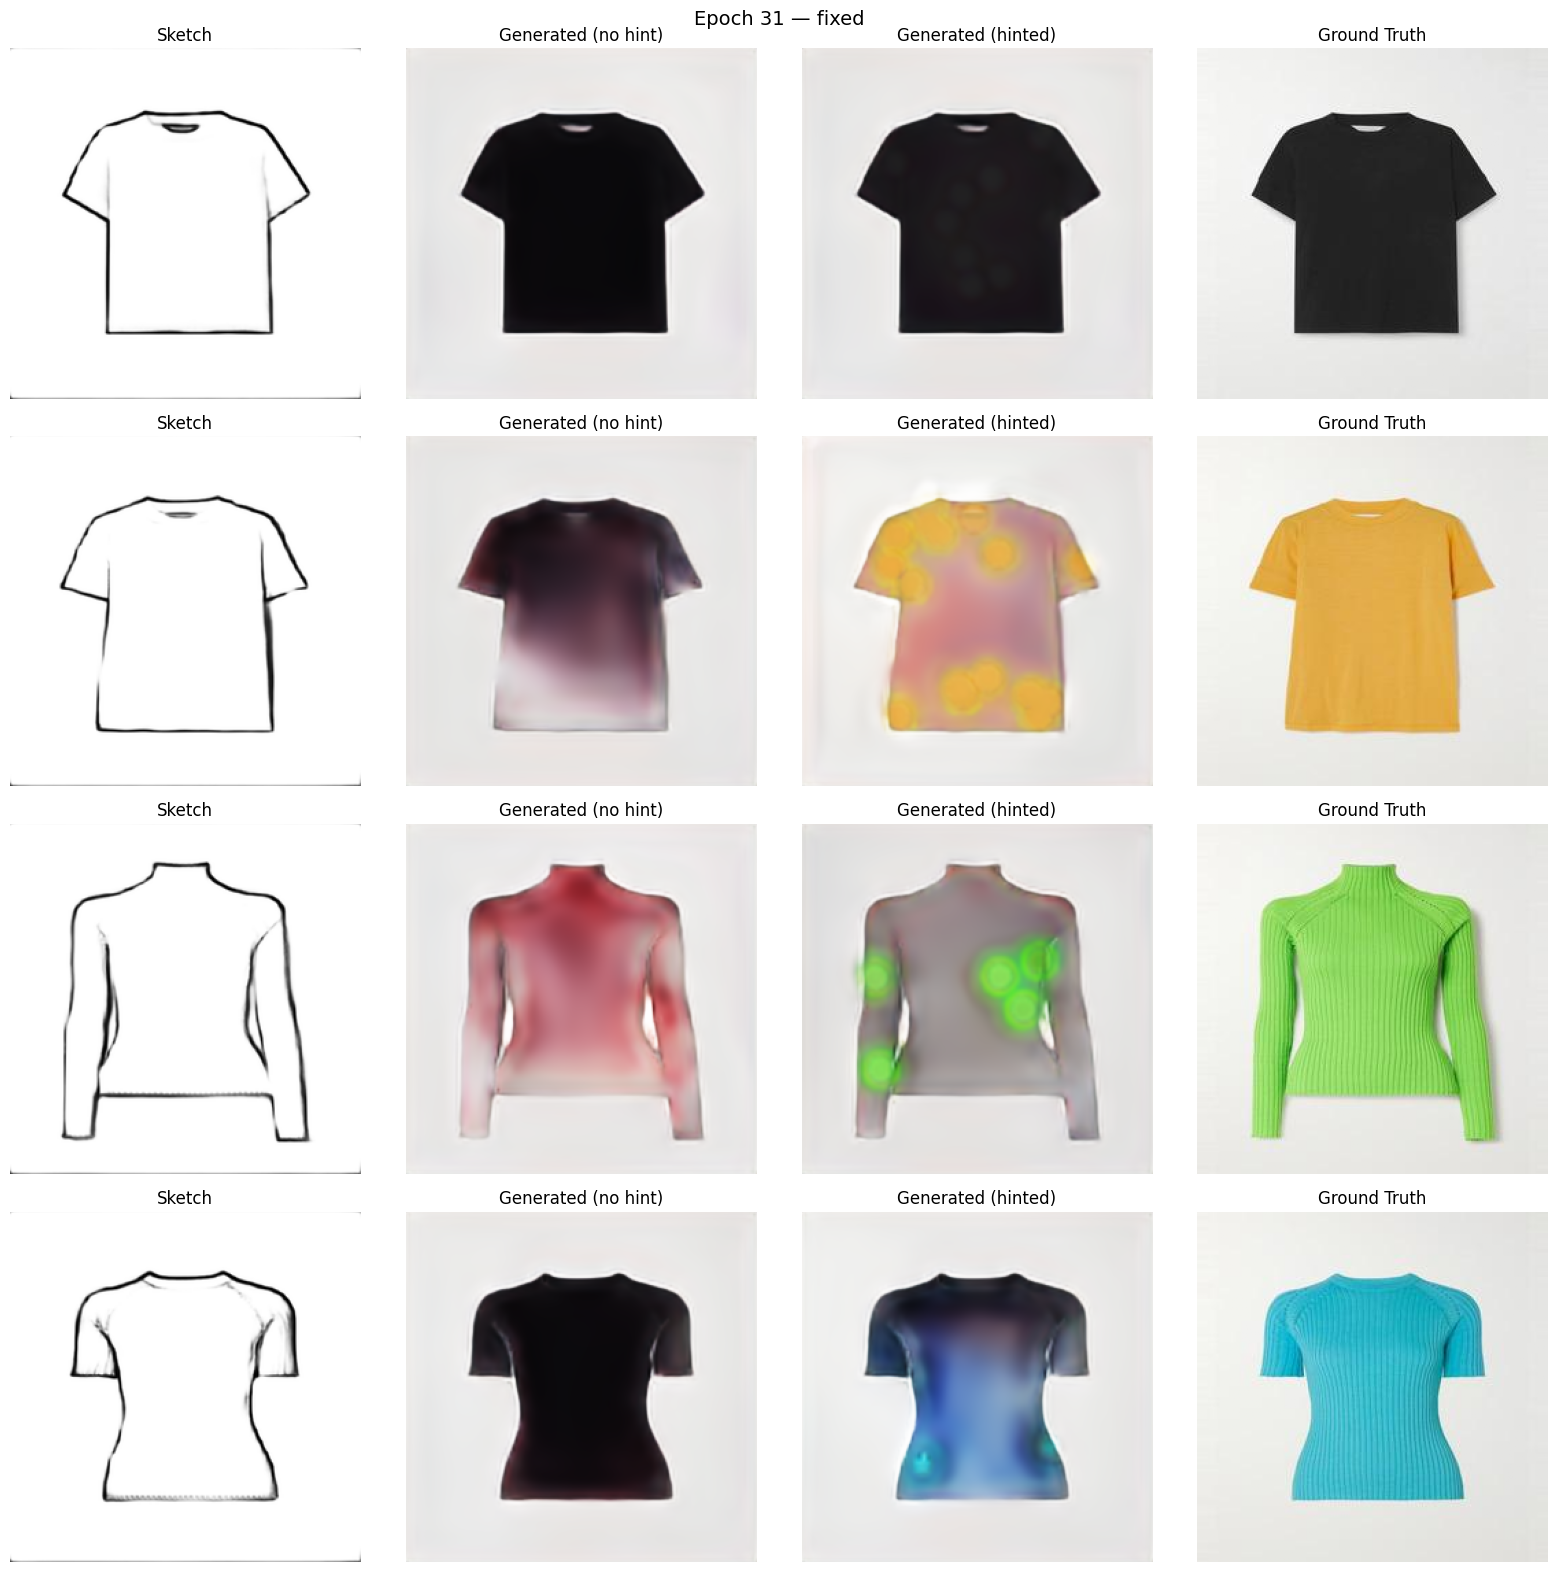

Samples saved: /kaggle/working/samples/epoch_0031_fixed.png


Epoch 32/40: 100%|████████████████████████████████████| 10760/10760 [17:55<00:00, 10.00it/s, G=28.5473, D=0.3252, GAN=2.3115, L1=25.2390, hint=0.9967]



Epoch 32/40 | G: 13.0586  D: 0.3253  GAN: 2.3029  L1: 7.2051  Hint: 3.5507  LR_G: 9.00e-05
  [Val Epoch 32]  Hinted  → L1: 0.1864  PSNR: 15.66 dB  |  No-hint → L1: 0.2862  PSNR: 12.47 dB
  [Log] epoch 32 written → /kaggle/working/logs/training_log.csv
Checkpoint saved: epoch 32


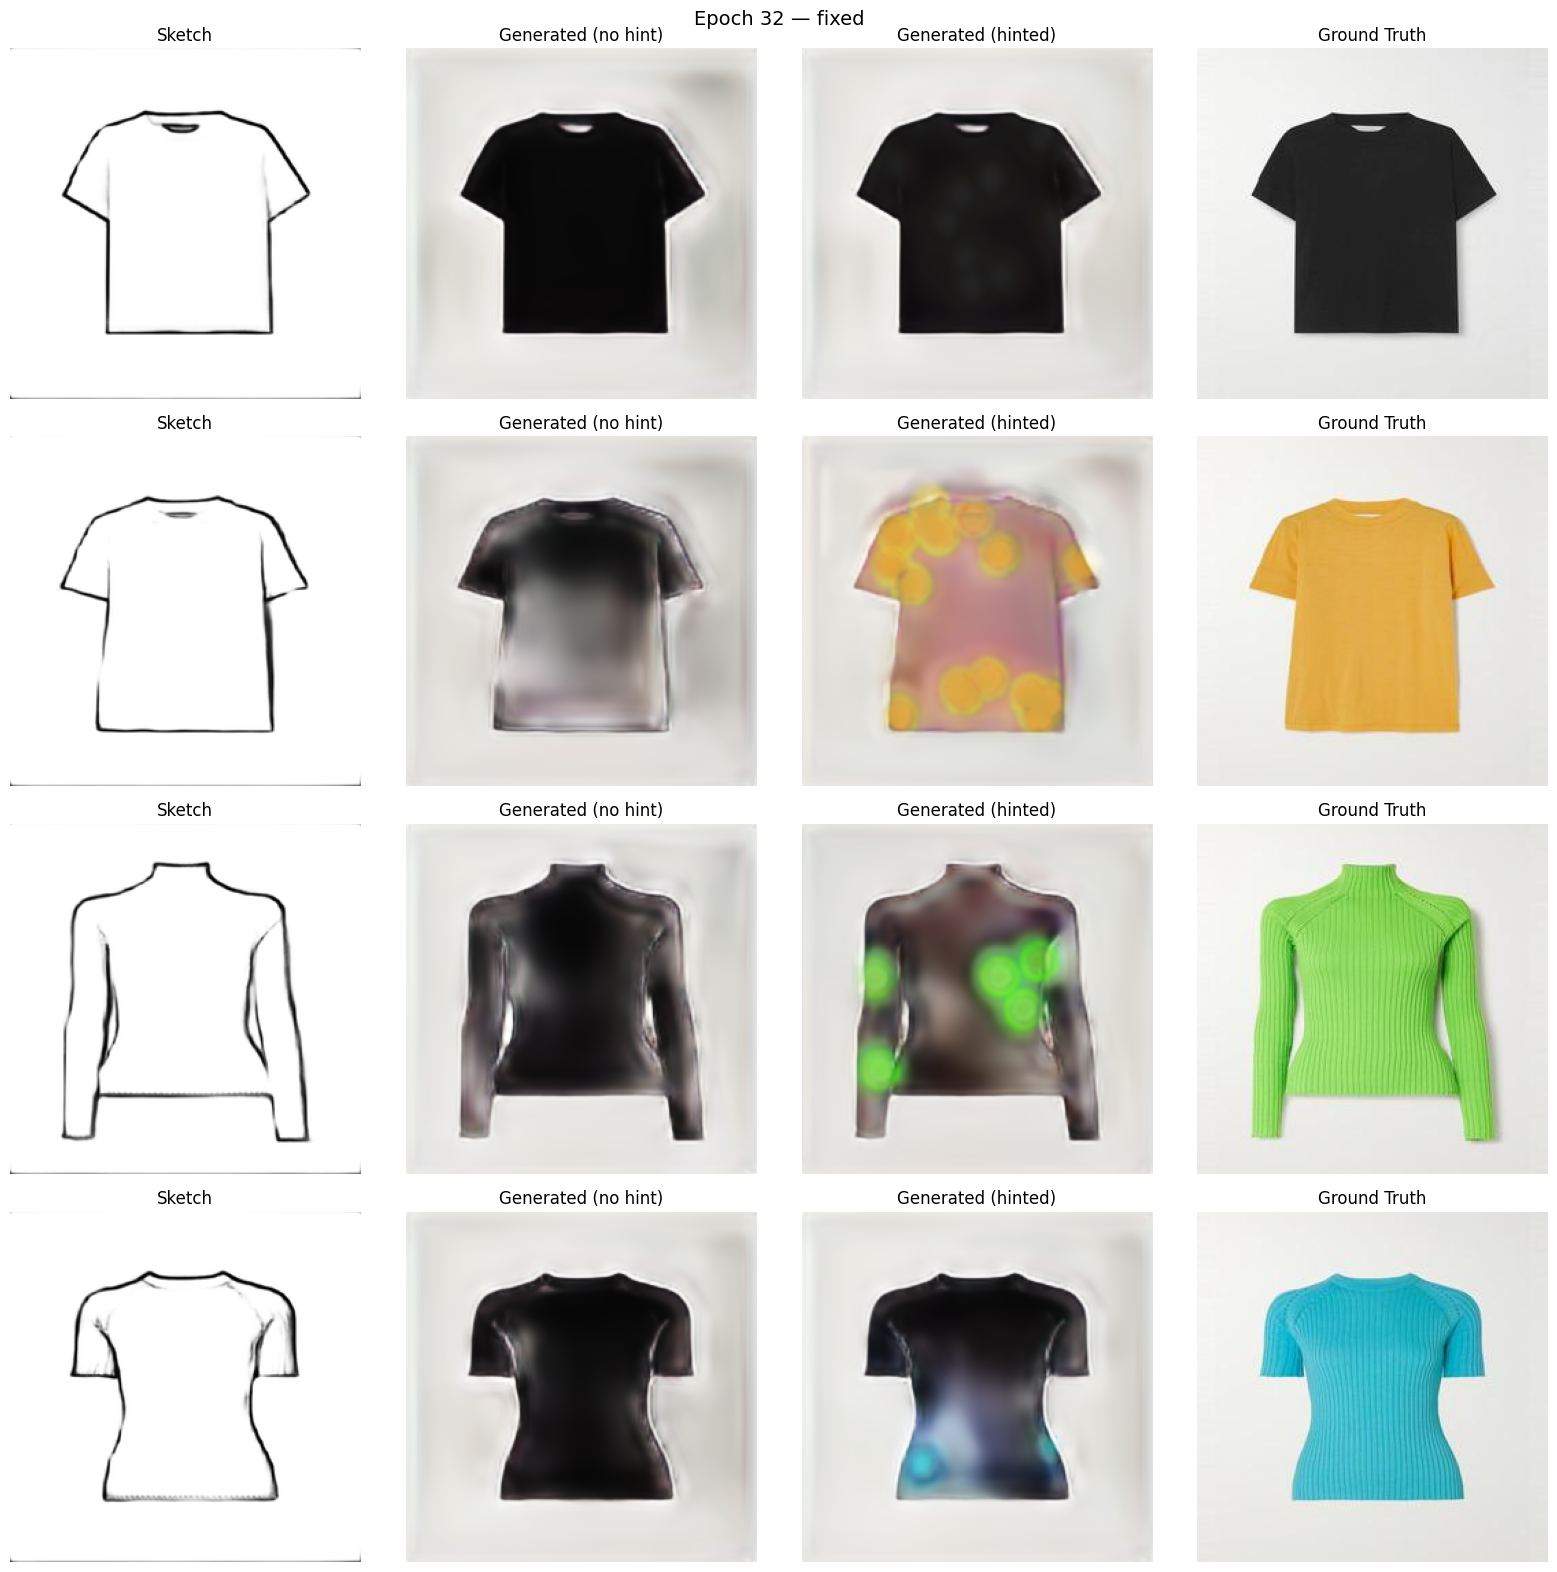

Samples saved: /kaggle/working/samples/epoch_0032_fixed.png


Epoch 33/40:  25%|█████████▉                             | 2739/10760 [04:36<13:29,  9.91it/s, G=9.5879, D=0.3252, GAN=2.3077, L1=4.6945, hint=2.5857]


KeyboardInterrupt: 

In [24]:
from tqdm import tqdm

def train():
    start_epoch = maybe_resume()
    load_existing_logs()   # restore log history on resume
    steps_per_epoch = len(train_loader)

    # ── fixed val batch — deterministic, seed-locked hints ─────────────────
    # We build this manually with a fixed numpy/torch seed so the same
    # val sketches always get identical hint locations and colors,
    # making epoch-to-epoch visual comparison meaningful.
    _VAL_SEED   = 42
    _VAL_N      = CONFIG['batch_size']   # how many fixed samples to track
    _rng_state  = np.random.get_state()  # save current RNG state
    np.random.seed(_VAL_SEED)
    torch.manual_seed(_VAL_SEED)
    fixed_inp, fixed_gt, fixed_hint_mask = next(iter(
        DataLoader(val_dataset, batch_size=_VAL_N, shuffle=False,
                   num_workers=0, worker_init_fn=lambda _: np.random.seed(_VAL_SEED))
    ))
    np.random.set_state(_rng_state)      # restore RNG so training stays stochastic
    torch.seed()                         # restore torch to non-deterministic

    # ── metric history for optional post-training plotting ──
    history = {'g_loss': [], 'd_loss': [],
               'val_l1_hinted': [], 'val_l1_nohint': [],
               'val_psnr_hinted': [], 'val_psnr_nohint': []}

    for epoch in range(start_epoch, CONFIG['epochs']):
        G.train()
        D.train()

        g_losses, d_losses = [], []
        gan_losses, l1_losses, hint_losses = [], [], []

        pbar = tqdm(train_loader, total=steps_per_epoch,
                    desc=f"Epoch {epoch+1}/{CONFIG['epochs']}", ncols=150)

        for step, (inp, gt, hint_mask) in enumerate(pbar):
            inp       = inp.to(device)        # (B, 4, H, W)
            gt        = gt.to(device)         # (B, 3, H, W)
            hint_mask = hint_mask.to(device)  # (B, 1, H, W)

            # ════════════════════════════════════════
            # DISCRIMINATOR STEP
            # ════════════════════════════════════════
            optimizer_D.zero_grad()
            with autocast():
                fake = G(inp)

                # D receives full inp (sketch + color hint) as condition
                pred_real = D(inp, gt)
                pred_fake = D(inp, fake.detach())

                loss_D_real = criterion_GAN(pred_real, torch.ones_like(pred_real)  * 0.9)  # label smoothing
                loss_D_fake = criterion_GAN(pred_fake, torch.zeros_like(pred_fake) + 0.1)
                loss_D      = (loss_D_real + loss_D_fake) * 0.5

            scaler.scale(loss_D).backward()
            scaler.step(optimizer_D)

            # ════════════════════════════════════════
            # GENERATOR STEP  (1:1 with D)
            # ════════════════════════════════════════
            optimizer_G.zero_grad()
            with autocast():
                fake      = G(inp)
                pred_fake = D(inp, fake)

                loss_G_GAN  = criterion_GAN(pred_fake, torch.ones_like(pred_fake))
                loss_G_L1   = criterion_L1(fake, gt) * CONFIG['lambda_l1']

                # ── hint-consistency loss ──────────────────────────────────
                # Computes L1 only on hint pixels. Zero when no hints present.
                loss_G_hint = hint_consistency_loss(fake, gt, hint_mask) * CONFIG['lambda_hint']

                loss_G = loss_G_GAN + loss_G_L1 + loss_G_hint

            scaler.scale(loss_G).backward()
            scaler.step(optimizer_G)
            scaler.update()

            # ── logging ──
            g_losses.append(loss_G.item())
            d_losses.append(loss_D.item())
            gan_losses.append(loss_G_GAN.item())
            l1_losses.append(loss_G_L1.item())
            hint_losses.append(loss_G_hint.item())

            pbar.set_postfix({
                "G":    f"{loss_G.item():.4f}",
                "D":    f"{loss_D.item():.4f}",
                "GAN":  f"{loss_G_GAN.item():.4f}",
                "L1":   f"{loss_G_L1.item():.4f}",
                "hint": f"{loss_G_hint.item():.4f}",
            })

        # ── end of epoch ──
        mean_g    = np.mean(g_losses)
        mean_d    = np.mean(d_losses)
        mean_gan  = np.mean(gan_losses)
        mean_l1   = np.mean(l1_losses)
        mean_hint = np.mean(hint_losses)

        print(f"\nEpoch {epoch+1}/{CONFIG['epochs']} | "
              f"G: {mean_g:.4f}  D: {mean_d:.4f}  "
              f"GAN: {np.mean(gan_losses):.4f}  "
              f"L1: {np.mean(l1_losses):.4f}  "
              f"Hint: {np.mean(hint_losses):.4f}  "
              f"LR_G: {scheduler_G.get_last_lr()[0]:.2e}")

        # ── dual-mode validation ──
        val_metrics = run_validation(fixed_inp, fixed_gt, fixed_hint_mask, epoch + 1)
        for k, v in val_metrics.items():
            history.setdefault(k, []).append(v)

        history['g_loss'].append(mean_g)
        history['d_loss'].append(mean_d)

        # ── log epoch metrics ──
        train_metrics = {
            'g_loss':    mean_g,
            'd_loss':    mean_d,
            'loss_gan':  mean_gan,
            'loss_l1':   mean_l1,
            'loss_hint': mean_hint,
            'lr_G':      scheduler_G.get_last_lr()[0],
            'lr_D':      scheduler_D.get_last_lr()[0],
        }
        log_epoch(epoch + 1, train_metrics, val_metrics)

        # ── step LR schedulers ──
        scheduler_G.step()
        scheduler_D.step()

        # ── save checkpoint ──
        save_checkpoint(epoch + 1, mean_g, mean_d)

        # ── fixed val visual panel ──
        save_samples(epoch + 1, fixed_inp, fixed_gt, label='fixed')

    # ── save final generator ──
    torch.save(G.state_dict(), '/kaggle/working/pix2pix_generator_final.pth')
    print("\nTraining complete. Final generator saved.")
    return history


history = train()

## Plot Training History

In [ ]:
epochs = range(1, len(history['g_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(epochs, history['g_loss'], label='G loss')
axes[0].plot(epochs, history['d_loss'], label='D loss')
axes[0].set_title('Train Losses'); axes[0].legend()

axes[1].plot(epochs, history.get('val_l1_hinted',  []), label='L1 hinted')
axes[1].plot(epochs, history.get('val_l1_nohint',  []), label='L1 no-hint')
axes[1].set_title('Val L1 (lower = better)'); axes[1].legend()

axes[2].plot(epochs, history.get('val_psnr_hinted', []), label='PSNR hinted')
axes[2].plot(epochs, history.get('val_psnr_nohint', []), label='PSNR no-hint')
axes[2].set_title('Val PSNR (higher = better)'); axes[2].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=100)
plt.show()
print("History plot saved.")

## Save Final Artefacts

In [31]:
import shutil
!zip -r logs32.zip /kaggle/working/logs



  adding: kaggle/working/logs/ (stored 0%)
  adding: kaggle/working/logs/training_log.json (deflated 72%)
  adding: kaggle/working/logs/training_log.csv (deflated 55%)


In [32]:
from IPython.display import FileLink
FileLink(r'logs32.zip') 

/kaggle/working/logs32.zip

In [ ]:
import shutil

import os

src = '/kaggle/input/datasets/humnafaisal1/checkpoint10' 

print(os.listdir(src))  

for f in os.listdir(src):

    shutil.copy(os.path.join(src, f), 

                os.path.join(CONFIG['checkpoint_dir'], f))

print("Restored:", os.listdir(CONFIG['checkpoint_dir']))